
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!ls drive/MyDrive/Machine\ Learning\ для\ людей/МОДУЛЬ\ 2

'2. Лінійна регресія'				        medical-charges.csv
 cars.csv					        medical-charges.gsheet
'HW 2.1. Аналіз ознак для побудови лінійної регресії'


In [33]:
medical_df = pd.read_csv("drive/MyDrive/Machine Learning для людей/МОДУЛЬ 2/medical-charges.csv")

In [34]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Ідеї для аналізу та прогнозування колонки charges без ML методів

- Перевірити кореляцію між `charges` та числовими змінними, такими як `age`, `bmi`, `children`. Наприклад, з'язувати, чи зі зростанням цих показників збільшуються витрати.

- розділити дані на групи за категоріальними змінними (`sex`, `smoker`, `region`) і обчислити середні витрати дял кожної з груп, щоб побачити які групи сприяють підвищенню витрат.

- проаналізувати взаємодію змінних, наприклад, між `smoker` i `bmi`, `region` i `age` для виявлення підгруп, які значно впливають на `charges`.

- створити графіки (scatter plot, box plot, bar plot), щоб зрозуміти, як змінюються витрати залежно від різних змінних.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [35]:
fig = px.histogram(medical_df,
                   x = 'charges',
                   marginal = 'box',
                   color = 'sex',
                   color_discrete_sequence = ['pink', 'blue'],
                   title = "Distribution of charges by sex")
fig.update_layout(bargap = 0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

- Для більшості клієнтів річні медичні збори становлять менше \$14,000. Тільки невелика частина клієнтів має вищі медичні збори, можливо, через нещасні випадки, серйозні хвороби та генетичні захворювання. Розподіл слідує "степеневому закону".

- Не існує значної різниця в медичних зборах між жінками та чоловіками. Медіана для обох груп становить приблизно \$9400.


In [36]:
fig = px.histogram(medical_df,
                   x = 'charges',
                   marginal = 'box',
                   color = 'region',
                   color_discrete_sequence = ['orange', 'yellow', 'black', 'purple'],
                   title = "Distribution of charges by regions")
fig.update_layout(bargap = 0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

- Для більшості клієнтів річні медичні збори становлять менше \$14,000. Тільки невелика частина клієнтів має вищі медичні збори, можливо, через нещасні випадки, серйозні хвороби та генетичні захворювання. Розподіл слідує "степеневому закону".

- Не існує як такої значної різниця в медичних зборах в різних регіонах. Однак регіон Southeast виділяється як той, що має найбільшу варіативність ознак, включаючи екстремальні значення.
Медіани `northwest` i `southwest`(\$8900 і \$8800 відповідно) не значно менші за медіани `northeast` i `southeast`(\$10000 і \$9300 відповідно).

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [37]:
fig = px.histogram(medical_df,
                 x = 'region',
                 color = 'smoker',
                 barmode = 'group',
                 title = "Region vs. Smoker")
fig.update_layout(bargap = 0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

- У всіх регіонах лідирує кількість клієнтів, які не курять.
- Найбільша кількість курців знаходиться в `southeast` регіоні.


In [38]:
fig = px.histogram(medical_df,
                 x = 'children',
                 color = 'smoker',
                 barmode = 'group',
                 title = "Children vs. Smoker")
fig.update_layout(bargap = 0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

- чим менше дітей мають клієнти, ти більше вони курять.


**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [39]:
fig = px.violin(medical_df,
                 x = 'children',
                 y = 'charges',
                 title = "Children vs. Charges")
fig.update_layout(bargap = 0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

- клієнти, які не маюьть дітей, або від 1 до 4, мають набагато ширший діапазон цін на страхування, ніж ті, у кого 5;

- клієнти з 4 дітьми, в середньому платять найбільшу суму за медичне страхування, що дорівнює приблизно `$11000`;

- з клієнтів, у яких 5 дітей, стягується найменше коштів, приблизно `$8600`;


**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [40]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [41]:
def estimate_charges(age, w, b):
    return w * age + b

In [42]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

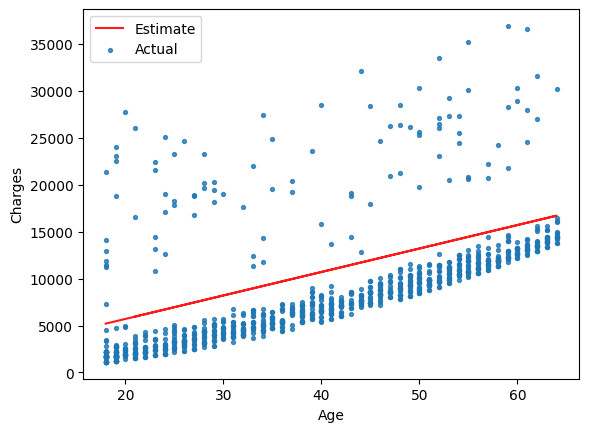

In [61]:
try_parameters(non_smoker_df, 250, 700)

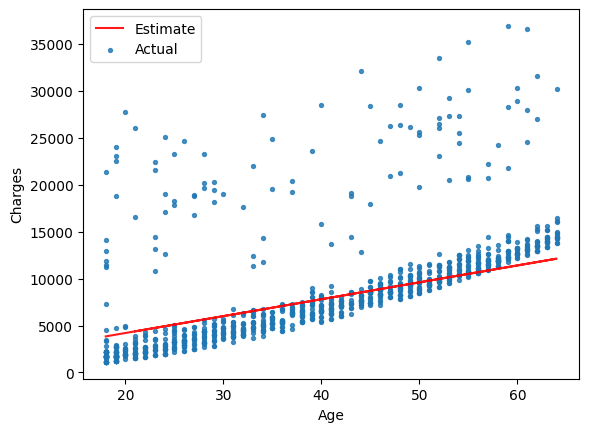

In [80]:
try_parameters(non_smoker_df, 180, 600)

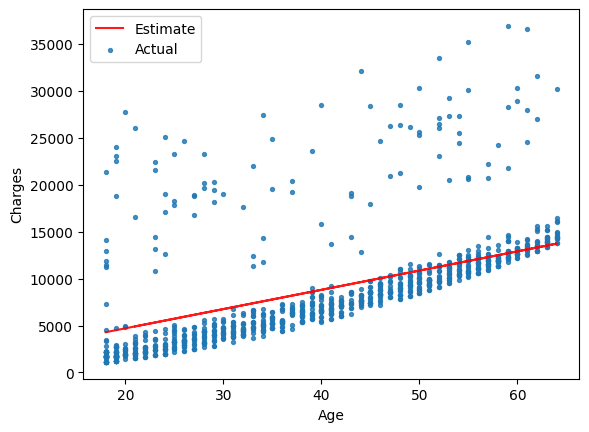

In [76]:
try_parameters(non_smoker_df, 205, 600)

**Спостереження**

Роль парметрів:

w: визначає нахил лінії.
Якщо 𝑤>0, то лінія зростає (припускаємо, що витрати збільшуються з віком).
Чим більше значення 𝑤, тим крутіший нахил.

b: визначає, де лінія перетинає вісь `charges` (значення, коли `age` = 0).

Бачимо, що параметри w = 205 i b = 600 є візуально найближчими до зосередженого розподілу даних.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [85]:
targets = non_smoker_df.charges


In [86]:
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square((targets - predictions))))

In [89]:
predictions = estimate_charges(non_smoker_df.age, 250, 700)
rmse(targets, predictions)

5124.32828785501

In [92]:
predictions = estimate_charges(non_smoker_df.age, 180, 600)
rmse(targets, predictions)

4878.758509059408

In [91]:
predictions = estimate_charges(non_smoker_df.age, 205, 600)
rmse(targets, predictions)

4750.186182944346

In [88]:
medical_df.charges.describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


**Інтерпретація RMSE**

*В середньому, кожен елемент у прогнозі відрізняється від фактичної цілі на \$13270.*

Результати наших обчислень (loss) вказують на те, наскільки погано модель прогнозує цільові змінні. Логічно, що *чим нижче втрата, тим краща модель*.

Бачимо, що парметри w = 205, b = 600 мають найменшу втрату, що дорівнює приблизно \$4750, тоді як модель з парметрами w = 250, b = 700 має найбільшу втрату приблизно \$5124.

**Стартегія для знаходження кращих значень w i b:**

1. Перебирати числами з великого діапазону, поступово зменшуючи його для уточнення.
2. Якщо лінія недооцінює значення по y, потрібно збільшити b.
3. Якщо нахил лінії занадто крутий, потрібно зменшити w.
4. Постійно будувати графіки, щоб бачити як перміщується і змінюється лінія.
5. Обрати ті параметри, для яких loss найменший.